## Cell 1 - Install & Import

In [1]:
!pip install neat-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 1.7 MB/s eta 0:00:00


In [2]:
import neat
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import display, update_display
import time
import pickle
import gzip
import heapq
from pathlib import Path
import math

## Cell 2 - Constants & Config

In [3]:
# ── Map size ──────────────────────────────────────────────
MIN_WIDTH,  MAX_WIDTH  = 14, 14
MIN_HEIGHT, MAX_HEIGHT = 14, 14

# ── Training ──────────────────────────────────────────────
MAPS_PER_GENOME = 24
MAX_GEN         = 200
POP_SIZE        = 50
LAMBDA_ARCHIVE  = 1
MODEL_PATH      = "neat_winner.pkl"
MAP_TXT_DIR     = "saved_maps_txt"
SEEDS           = [0, 1, 2, 3, 4]              # test 1 seed; doi thanh [0,1,2,3,4] khi train day du

# ── Tile types ────────────────────────────────────────────
WALL   = 0
FLOOR  = 1
PLAYER = 2
ENEMY  = 3
N_TILE_TYPES = 4

TILE_COLORS = {
    WALL:   [0.2,  0.2,  0.2],
    FLOOR:  [0.95, 0.95, 0.95],
    PLAYER: [0.2,  0.8,  0.2],
    ENEMY:  [0.9,  0.2,  0.2],
}

# ── Novelty Search weights ────────────────────────────────
NOVELTY_K           = 15
NOVELTY_W_SOLVABLE  = 0.20
NOVELTY_W_INTRA     = 0.33
NOVELTY_W_INTER     = 0.32
NOVELTY_W_ME        = 0.05
NOVELTY_W_BRANCH    = 0.10  # branching fitness — rewards T/+ junctions, breaks all stripe patterns
ARCHIVE_MAX_SIZE    = 500

# ── MAP-Elites grid (path_len x wall_dens) ───────────────
ME_PATH_BINS   = [0.5, 1.0, 1.5]   # 4 bins: <0.5 | 0.5-1.0 | 1.0-1.5 | >=1.5
ME_WALL_BINS   = [0.2, 0.4, 0.6]   # 4 bins: <0.2 | 0.2-0.4 | 0.4-0.6 | >=0.6
ME_ROWS        = len(ME_PATH_BINS) + 1   # 4
ME_COLS        = len(ME_WALL_BINS) + 1   # 4
ME_TOTAL_CELLS = ME_ROWS * ME_COLS       # 16

# ── Input encoding ────────────────────────────────────────
CONTEXT_SIZE      = 1
CTX_TILES         = (2*CONTEXT_SIZE+1)**2 - 1   # 8
NUM_RANDOM_INPUTS = 4
NUM_INPUTS        = CTX_TILES + NUM_RANDOM_INPUTS  # 12
NUM_OUTPUTS       = 1

_w_sum = NOVELTY_W_SOLVABLE + NOVELTY_W_INTER + NOVELTY_W_INTRA + NOVELTY_W_ME
print(f"Inputs : {NUM_INPUTS}  |  Seeds: {SEEDS}")
print(f"Maps/genome: {MAPS_PER_GENOME}")
print(f"Weights: solve={NOVELTY_W_SOLVABLE}, inter={NOVELTY_W_INTER}, intra={NOVELTY_W_INTRA}, me={NOVELTY_W_ME}")
print(f"Weight sum = {_w_sum:.4f}  {'OK' if abs(_w_sum - 1.0) < 1e-6 else 'NOT 1.0'}")
print(f"MAP-Elites: {ME_ROWS}x{ME_COLS} = {ME_TOTAL_CELLS} cells")


Inputs : 12  |  Seeds: [0, 1, 2, 3, 4]
Maps/genome: 24
Weights: solve=0.2, inter=0.32, intra=0.33, me=0.05
Weight sum = 0.9000  NOT 1.0
MAP-Elites: 4x4 = 16 cells


## Cell 3 - Map Generation (3×3 Context theo paper PCGNN)

In [4]:
PERTURB_SIZE = 0.1565   # paper Table 9 Maze

def generate_level(net, map_h=None, map_w=None, perturb=True):
    if hasattr(net, 'reset'): net.reset()
    if map_h is None: map_h = random.randint(MIN_HEIGHT, MAX_HEIGHT)
    if map_w is None: map_w = random.randint(MIN_WIDTH, MAX_WIDTH)

    half = CONTEXT_SIZE
    # Random padding: boundary context is random 0/1 each call
    # → network cannot learn a fixed "border = corridor" attractor
    padded = np.random.randint(0, 2, (map_h + 2*half, map_w + 2*half)).astype(float)
    noise = [random.gauss(0, 1) for _ in range(NUM_RANDOM_INPUTS)]

    for r in range(half, map_h + half):
        for c in range(half, map_w + half):
            ctx = []
            for dr in range(-half, half + 1):
                for dc in range(-half, half + 1):
                    if dr == 0 and dc == 0:
                        continue
                    ctx.append(padded[r + dr, c + dc])
            inputs = ctx + noise
            if perturb:
                inputs = [x + random.gauss(0, PERTURB_SIZE) for x in inputs]
            out = net.activate(inputs)[0]
            padded[r, c] = 1.0 if out > 0.5 else 0.0

    level = padded[half:half+map_h, half:half+map_w].astype(int)

    if level[0, 0] == FLOOR:
        level[0, 0] = PLAYER
    if level[map_h-1, map_w-1] == FLOOR:
        level[map_h-1, map_w-1] = ENEMY

    return level

def ensure_connectivity(level):
    h, w = level.shape

    def bfs(start):
        visited = set()
        q = deque([start])
        visited.add(start)
        while q:
            r, c = q.popleft()
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in visited and level[nr,nc] == FLOOR:
                    visited.add((nr,nc)); q.append((nr,nc))
        return visited

    all_floor = {(r,c) for r in range(h) for c in range(w) if level[r,c] == FLOOR}
    if not all_floor:
        for r in range(h):
            level[r, 0] = FLOOR
        return level

    remaining, regions = set(all_floor), []
    while remaining:
        reg = bfs(next(iter(remaining)))
        regions.append(reg); remaining -= reg

    regions.sort(key=len, reverse=True)
    main = regions[0]
    for reg in regions[1:]:
        _carve_corridor(level, reg, main, h, w)
        main |= reg
    return level


def _carve_corridor(level, src, dst, h, w):
    best, best_d = None, float('inf')
    src_s = list(src)[:30]; dst_s = list(dst)[:30]
    for r1,c1 in src_s:
        for r2,c2 in dst_s:
            d = abs(r1-r2)+abs(c1-c2)
            if d < best_d:
                best_d = d; best = (r1,c1,r2,c2)
    if best is None: return
    r1,c1,r2,c2 = best
    for c in range(min(c1,c2), max(c1,c2)+1):
        if 0 <= r1 < h and 0 <= c < w:
            level[r1, c] = FLOOR
    for r in range(min(r1,r2), max(r1,r2)+1):
        if 0 <= r < h and 0 <= c2 < w:
            level[r, c2] = FLOOR


def map_to_text(level):
    sym = {WALL:"#", FLOOR:".", PLAYER:"P", ENEMY:"E"}
    return "\n".join("".join(sym.get(int(t),"?") for t in row) for row in level)

def save_maps_to_txt(maps, prefix="map", out_dir=MAP_TXT_DIR):
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)
    for i, lvl in enumerate(maps, 1):
        h, w = lvl.shape
        (out / f"{prefix}_{i:02d}_{h}x{w}.txt").write_text(map_to_text(lvl), encoding="utf-8")

print("✅ Map generation loaded (paper scan order: left→right, top→bottom)")
print(f"   Input : {CTX_TILES} raw tiles + {NUM_RANDOM_INPUTS} noise = {NUM_INPUTS}")
print(f"   Output: 1 scalar, threshold >= 0.5 → FLOOR")
print(f"   Padding: random 0/1 | Corners: PLAYER=(0,0), ENEMY=(H-1,W-1) if FLOOR")

✅ Map generation loaded (paper scan order: left→right, top→bottom)
   Input : 8 raw tiles + 4 noise = 12
   Output: 1 scalar, threshold >= 0.5 → FLOOR
   Padding: random 0/1 | Corners: PLAYER=(0,0), ENEMY=(H-1,W-1) if FLOOR


## Cell 4 - Metrics (Solvability, Compression Distance, A* Diversity, Leniency)

In [5]:
# ─────────────────────────────────────────────────────────
# 4.1 Solvability (BFS player → enemy)
# ─────────────────────────────────────────────────────────
def is_solvable(level):
    h, w = level.shape
    ps = list(zip(*np.where(level == PLAYER)))
    es = set(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return False
    q, vis = deque([ps[0]]), {ps[0]}
    while q:
        r, c = q.popleft()
        if (r, c) in es: return True
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and level[nr,nc] != WALL:
                vis.add((nr,nc)); q.append((nr,nc))
    return False


def shortest_path_bfs(level):
    h, w = level.shape
    ps = list(zip(*np.where(level == PLAYER)))
    es = set(zip(*np.where(level == ENEMY)))
    if not ps or not es: return None
    q, vis = deque([(ps[0], 0)]), {ps[0]}
    while q:
        (r,c), d = q.popleft()
        if (r,c) in es: return d
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr,nc = r+dr,c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and level[nr,nc] != WALL:
                vis.add((nr,nc)); q.append(((nr,nc), d+1))
    return None


def path_diversity_fitness(levels):
    lengths = [shortest_path_bfs(lvl) for lvl in levels]
    lengths = [l for l in lengths if l is not None]
    if len(lengths) < 2:
        return 0.0
    max_path = MAX_HEIGHT + MAX_WIDTH
    return float(min(1.0, np.std(lengths) / max_path))


def reachability_ratio(level):
    h, w = level.shape
    walkable = (level == FLOOR) | (level == PLAYER) | (level == ENEMY)
    total = int(walkable.sum())
    if total == 0:
        return 0.0
    visited = np.zeros_like(walkable, dtype=bool)
    best = 0
    for r in range(h):
        for c in range(w):
            if walkable[r, c] and not visited[r, c]:
                size = 0
                q = deque([(r, c)])
                visited[r, c] = True
                while q:
                    y, x = q.popleft()
                    size += 1
                    for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
                        ny, nx = y+dy, x+dx
                        if 0 <= ny < h and 0 <= nx < w and walkable[ny, nx] and not visited[ny, nx]:
                            visited[ny, nx] = True
                            q.append((ny, nx))
                if size > best:
                    best = size
    return best / total


# ─────────────────────────────────────────────────────────
# 4.2 Compression Distance
# ─────────────────────────────────────────────────────────
def _level_to_str(level) -> str:
    l = level.copy()
    l[l == PLAYER] = FLOOR
    l[l == ENEMY]  = FLOOR
    return ''.join(map(str, l.flatten()))

def compression_distance(level_a, level_b) -> float:
    def C(z): return len(gzip.compress(bytes(z, 'utf-8')))
    x, y = _level_to_str(level_a), _level_to_str(level_b)
    denom = max(C(x), C(y))
    if denom == 0: return 0.0
    return (C(x + y) - min(C(x), C(y))) / denom


# ─────────────────────────────────────────────────────────
# 4.3 A* search
# ─────────────────────────────────────────────────────────
def _astar(level, start, end):
    h, w = level.shape
    def heuristic(pos):
        return abs(pos[0] - end[0]) + abs(pos[1] - end[1])
    counter = 0
    open_set = [(heuristic(start), counter, start)]
    came_from = {start: None}
    g_score = {start: 0}
    visited = set()
    while open_set:
        _, _, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current == end:
            path = []
            node = end
            while node is not None:
                path.append(node)
                node = came_from[node]
            return list(reversed(path)), len(visited)
        r, c = current
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < h and 0 <= nc < w and (nr,nc) not in visited and level[nr,nc] != WALL:
                new_g = g_score[current] + 1
                if new_g < g_score.get((nr,nc), float('inf')):
                    came_from[(nr,nc)] = current
                    g_score[(nr,nc)] = new_g
                    counter += 1
                    heapq.heappush(open_set, (new_g + heuristic((nr,nc)), counter, (nr,nc)))
    return None, len(visited)

def _get_astar_result(level):
    ps = list(zip(*np.where(level == PLAYER)))
    es = list(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return None, 0
    start = ps[0]
    end = min(es, key=lambda e: abs(e[0]-start[0]) + abs(e[1]-start[1]))
    return _astar(level, start, end)


# ─────────────────────────────────────────────────────────
# 4.4 A* Diversity
# ─────────────────────────────────────────────────────────
def _sample_trajectory(traj, N=30):
    if not traj: return [(0,0)] * N
    return [traj[int(i * len(traj) / N)] for i in range(N)]

def astar_diversity(level_a, level_b, N=30) -> float:
    path_a, _ = _get_astar_result(level_a)
    path_b, _ = _get_astar_result(level_b)
    if not path_a: path_a = [(0,0)]
    if not path_b: path_b = [(0,0)]
    sa = _sample_trajectory(path_a, N)
    sb = _sample_trajectory(path_b, N)
    if len(sa) < len(sb):
        sa += [sa[-1]] * (len(sb) - len(sa))
    elif len(sb) < len(sa):
        sb += [sb[-1]] * (len(sa) - len(sb))
    h, w = level_a.shape
    norm = w + h
    return float(np.mean([
        (abs(a[0]-b[0]) + abs(a[1]-b[1])) / norm
        for a, b in zip(sa, sb)
    ]))


# ─────────────────────────────────────────────────────────
# 4.5 A* Edit Diversity
# ─────────────────────────────────────────────────────────
def _path_to_actions(path):
    actions = []
    for i in range(1, len(path)):
        dr = path[i][0] - path[i-1][0]
        dc = path[i][1] - path[i-1][1]
        dr_m = 2 if dr == -1 else dr
        dc_m = 2 if dc == -1 else dc
        actions.append(dr_m * 3 + dc_m)
    return actions if actions else [0]

def _levenshtein(s, t):
    m, n = len(s), len(t)
    d = list(range(n+1))
    for i in range(1, m+1):
        prev, d[0] = d[:], i
        for j in range(1, n+1):
            cost = 0 if s[i-1] == t[j-1] else 1
            d[j] = min(prev[j]+1, d[j-1]+1, prev[j-1]+cost)
    return d[n]

def astar_edit_diversity(level_a, level_b) -> float:
    path_a, _ = _get_astar_result(level_a)
    path_b, _ = _get_astar_result(level_b)
    if not path_a: path_a = [(0,0)]
    if not path_b: path_b = [(0,0)]
    def get_char(x): return str(x) if x < 10 else chr(x - 10 + 65)
    sa = ''.join(map(get_char, _path_to_actions(path_a)))
    sb = ''.join(map(get_char, _path_to_actions(path_b)))
    denom = max(len(sa), len(sb))
    return _levenshtein(sa, sb) / denom if denom else 0.0


# ─────────────────────────────────────────────────────────
# 4.6 A* Difficulty
# ─────────────────────────────────────────────────────────
def astar_difficulty(level) -> float:
    path, num_considered = _get_astar_result(level)
    if path is None:
        return 0.0
    num_passable = max(1, int((level != WALL).sum()) - len(path))
    return max(num_considered - len(path), 0) / num_passable


# ─────────────────────────────────────────────────────────
# 4.7 Leniency
# ─────────────────────────────────────────────────────────
def leniency(level) -> float:
    h, w = level.shape
    walkable = {FLOOR, PLAYER, ENEMY}
    ps = list(zip(*np.where(level == PLAYER)))
    es = list(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return 0.0
    start = ps[0]
    end = min(es, key=lambda e: abs(e[0]-start[0]) + abs(e[1]-start[1]))

    def bfs_path(grid, src, dst):
        q = deque([(src, [src])])
        vis = {src}
        while q:
            (r, c), path = q.popleft()
            if (r, c) == dst: return path
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and grid[nr,nc] in walkable:
                    vis.add((nr,nc)); q.append(((nr,nc), path+[(nr,nc)]))
        return None

    def reachable_cells(grid, src):
        vis, q = {src}, deque([src])
        while q:
            r, c = q.popleft()
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and grid[nr,nc] in walkable:
                    vis.add((nr,nc)); q.append((nr,nc))
        return vis

    if bfs_path(level, start, end) is None:
        return 0.0
    coords = reachable_cells(level, start)
    non_blocked = 0
    for (r, c) in coords:
        if (r, c) == start or (r, c) == end:
            non_blocked += 1; continue
        path_to = bfs_path(level, start, (r, c))
        if path_to is None:
            non_blocked += 1; continue
        tmp = level.copy()
        for pr, pc in path_to[:-1]:
            tmp[pr, pc] = WALL
        if bfs_path(tmp, (r, c), end) is not None:
            non_blocked += 1
    return non_blocked / len(coords)


# ─────────────────────────────────────────────────────────
# 4.8 Visual Diversity
# ─────────────────────────────────────────────────────────
def visual_diversity(level_a, level_b) -> float:
    def strip(lvl):
        l = lvl.copy(); l[l==PLAYER]=FLOOR; l[l==ENEMY]=FLOOR
        return l
    a = strip(level_a).flatten()
    b = strip(level_b).flatten()
    n = min(len(a), len(b))
    return float(np.mean(a[:n] != b[:n]))


# ─────────────────────────────────────────────────────────
# 4.9 Behavior Characterization — 4-dim BC vector
# [wall_dens, path_norm, dead_norm, regions_norm]
# Removed: branch_norm (diagonal maps have many junctions → was rewarding diagonals)
# Removed: astar_diff (correlated with path_norm)
# Removed: turns_norm (zigzag attractor)
# ─────────────────────────────────────────────────────────
def behavior_characterization(level):
    h, w = level.shape
    walkable = {FLOOR, PLAYER, ENEMY}

    interior = level[1:-1, 1:-1]
    wall_dens = float(np.sum(interior == WALL) / max(1, interior.size))

    sp = shortest_path_bfs(level)
    path_norm = min(1.0, (sp / (h + w)) if sp else 0.0)

    dead_ends = 0
    for r in range(h):
        for c in range(w):
            if level[r, c] not in walkable: continue
            nb = sum(1 for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]
                     if 0<=r+dr<h and 0<=c+dc<w and level[r+dr,c+dc] in walkable)
            if nb == 1: dead_ends += 1
    total_walk = max(1, int((level != WALL).sum()))
    dead_norm = dead_ends / total_walk

    visited = np.zeros((h, w), dtype=bool)
    regions = 0
    for r0 in range(h):
        for c0 in range(w):
            if level[r0, c0] in walkable and not visited[r0, c0]:
                regions += 1
                q = deque([(r0, c0)])
                visited[r0, c0] = True
                while q:
                    r, c = q.popleft()
                    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                        nr, nc = r+dr, c+dc
                        if 0<=nr<h and 0<=nc<w and not visited[nr,nc] and level[nr,nc] in walkable:
                            visited[nr,nc] = True
                            q.append((nr,nc))
    regions_norm = min(1.0, regions / 10.0)

    return np.array([wall_dens, path_norm, dead_norm, regions_norm], dtype=float)


# ─────────────────────────────────────────────────────────
# 4.10 Anti-mode-collapse
# ─────────────────────────────────────────────────────────
def density_extreme_penalty(level) -> float:
    interior = level[1:-1, 1:-1]
    dens = float(np.sum(interior == WALL) / max(1, interior.size))
    if dens < 0.15:
        return 1.0 - (dens / 0.15)
    if dens > 0.6:
        return min(1.0, (dens - 0.6) / 0.4)
    return 0.0


# ─────────────────────────────────────────────────────────
# 4.11 Cached level metrics
# ─────────────────────────────────────────────────────────
_level_cache = {}
_LEVEL_CACHE_MAX = 50000


def _astar_internal(level, start, end):
    h, w = level.shape
    counter = 0
    open_set = [(abs(start[0]-end[0]) + abs(start[1]-end[1]), counter, start)]
    came_from = {start: None}
    g_score = {start: 0}
    visited = set()
    while open_set:
        _, _, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current == end:
            path = []
            node = end
            while node is not None:
                path.append(node)
                node = came_from[node]
            return list(reversed(path)), len(visited)
        r, c = current
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in visited and level[nr,nc] != WALL:
                new_g = g_score[current] + 1
                if new_g < g_score.get((nr,nc), float('inf')):
                    came_from[(nr,nc)] = current
                    g_score[(nr,nc)] = new_g
                    counter += 1
                    heapq.heappush(open_set, (new_g + abs(nr-end[0]) + abs(nc-end[1]), counter, (nr,nc)))
    return None, len(visited)


def _compute_level_metrics(level):
    key = level.tobytes()
    cached = _level_cache.get(key)
    if cached is not None:
        return cached

    ps = list(zip(*np.where(level == PLAYER)))
    es = list(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        result = (None, 0, False, None)
    else:
        start = ps[0]
        end = min(es, key=lambda e: abs(e[0]-start[0]) + abs(e[1]-start[1]))
        path, considered = _astar_internal(level, start, end)
        solvable = path is not None and len(path) > 1
        sp_len = (len(path) - 1) if solvable else None
        result = (path, considered, solvable, sp_len)

    if len(_level_cache) >= _LEVEL_CACHE_MAX:
        items = list(_level_cache.items())
        _level_cache.clear()
        for k, v in items[len(items)//2:]:
            _level_cache[k] = v
    _level_cache[key] = result
    return result


def reset_level_cache():
    _level_cache.clear()


def is_solvable(level):
    return _compute_level_metrics(level)[2]

def shortest_path_bfs(level):
    return _compute_level_metrics(level)[3]

def _get_astar_result(level):
    path, considered, _, _ = _compute_level_metrics(level)
    return path, considered

print(f"✅ A* + BFS caching enabled (max cache {_LEVEL_CACHE_MAX} levels)")


# ─────────────────────────────────────────────────────────
# 4.12 MAP-Elites helpers
# ─────────────────────────────────────────────────────────
_ME_DENS_GOOD_MIN  = 0.15
_ME_DENS_GOOD_MAX  = 0.60
_ME_DENS_BIN_EDGES = [0.30, 0.45]
_ME_N_HT_BINS      = 4
_ME_N_DENS_BINS    = 3
_ME_TOTAL_CELLS    = _ME_N_HT_BINS * _ME_N_DENS_BINS

me_archive: dict = {}


def _me_ht_rate_bin(rate: float) -> int:
    if rate < 0.10: return 0
    if rate < 0.20: return 1
    if rate < 0.35: return 2
    return 3


def _me_density_bin(d: float):
    if d < _ME_DENS_GOOD_MIN or d > _ME_DENS_GOOD_MAX:
        return None
    for i, b in enumerate(_ME_DENS_BIN_EDGES):
        if d < b:
            return i
    return len(_ME_DENS_BIN_EDGES)


def _me_branching_fitness(levels, target=0.10) -> float:
    scores = []
    for lvl in levels:
        h, w = lvl.shape
        floor, branches = 0, 0
        for r in range(h):
            for c in range(w):
                if lvl[r, c] != WALL:
                    floor += 1
                    nb = sum(1 for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]
                             if 0<=r+dr<h and 0<=c+dc<w and lvl[r+dr,c+dc] != WALL)
                    if nb >= 3:
                        branches += 1
        scores.append(min(1.0, (branches / max(1, floor)) / target))
    return float(np.mean(scores)) if scores else 0.0


def interior_wall_density(level) -> float:
    interior = level[1:-1, 1:-1]
    return float(np.sum(interior == WALL) / interior.size)


# ─────────────────────────────────────────────────────────
# 4.13 BC vector cache — 4-dim, uniform weights
# ─────────────────────────────────────────────────────────
_bc_vec_cache = {}
_BC_VEC_CACHE_MAX = 10000
_BC_WEIGHTS_SUM_SQRT = float(np.sqrt(4.0))

def _bc_vec(level) -> np.ndarray:
    key = level.tobytes()
    if key not in _bc_vec_cache:
        if len(_bc_vec_cache) >= _BC_VEC_CACHE_MAX:
            items = list(_bc_vec_cache.items())
            _bc_vec_cache.clear()
            for k, v in items[len(items)//2:]:
                _bc_vec_cache[k] = v
        _bc_vec_cache[key] = behavior_characterization(level)
    return _bc_vec_cache[key]

def bc_distance(level_a, level_b) -> float:
    diff = _bc_vec(level_a) - _bc_vec(level_b)
    return float(np.sqrt(np.sum(diff * diff)) / _BC_WEIGHTS_SUM_SQRT)

def reset_bc_cache():
    _bc_vec_cache.clear()


# ─────────────────────────────────────────────────────────
# 4.14 Action sequence cache + intra_distance
# ─────────────────────────────────────────────────────────
_actions_cache = {}
_ACTIONS_CACHE_MAX = 10000

def _get_actions(level) -> list:
    key = level.tobytes()
    if key not in _actions_cache:
        if len(_actions_cache) >= _ACTIONS_CACHE_MAX:
            items = list(_actions_cache.items())
            _actions_cache.clear()
            for k, v in items[len(items)//2:]:
                _actions_cache[k] = v
        path, _ = _get_astar_result(level)
        _actions_cache[key] = _path_to_actions(path) if path else []
    return _actions_cache[key]

def _aed(level_a, level_b) -> float:
    act_a = _get_actions(level_a)
    act_b = _get_actions(level_b)
    if not act_a or not act_b:
        return 0.0
    min_len = min(len(act_a), len(act_b))
    if min_len == 0:
        return 0.0
    return sum(a != b for a, b in zip(act_a, act_b)) / min_len

def intra_distance(level_a, level_b, alpha=0.6) -> float:
    bc = bc_distance(level_a, level_b)
    act_a = _get_actions(level_a)
    act_b = _get_actions(level_b)
    if not act_a or not act_b:
        return bc
    return alpha * bc + (1.0 - alpha) * _aed(level_a, level_b)

def reset_aed_cache():
    _actions_cache.clear()

print("✅ Metrics loaded — BC: 4-dim [wall_dens, path_norm, dead_norm, regions_norm]")

✅ A* + BFS caching enabled (max cache 50000 levels)
✅ Metrics loaded — BC: 4-dim [wall_dens, path_norm, dead_norm, regions_norm]


## Cell 5 - Novelty Search (PCGNN core — đúng paper)

In [6]:
import copy
novelty_archive: list = []

# MAP-Elites archive: {(row, col): (fitness, levels)}
me_archive: dict = {}


def _generator_distance(levels_i, levels_j) -> float:
    n = min(len(levels_i), len(levels_j))
    if n == 0: return 0.0
    return float(np.mean([bc_distance(levels_i[k], levels_j[k]) for k in range(n)]))


def inter_novelty_score(levels_i, all_reference_level_lists, k=NOVELTY_K) -> float:
    if not all_reference_level_lists:
        return 0.0
    dists = sorted(_generator_distance(levels_i, ref) for ref in all_reference_level_lists)
    k_eff = min(k, len(dists))
    return float(np.mean(dists[:k_eff])) if k_eff > 0 else 0.0


def intra_novelty_score(levels, k=2) -> float:
    if len(levels) < 2:
        return 0.0
    scores = []
    for i, lvl_i in enumerate(levels):
        dists = sorted(intra_distance(lvl_i, lvl_j)
                       for j, lvl_j in enumerate(levels) if i != j)
        k_eff = min(k, len(dists))
        scores.append(np.mean(dists[:k_eff]))
    return float(np.mean(scores))


def solvability_fitness(levels) -> float:
    return float(np.mean([float(is_solvable(lvl)) for lvl in levels]))


# ── MAP-Elites helpers ─────────────────────────────────────
def _me_cell(level) -> tuple:
    sp = shortest_path_bfs(level)
    path_norm = min(2.0, (sp / (MAX_HEIGHT + MAX_WIDTH)) if sp else 0.0)
    wall = interior_wall_density(level)
    row = int(np.searchsorted(ME_PATH_BINS, path_norm))
    col = int(np.searchsorted(ME_WALL_BINS, wall))
    return row, col


def me_genome_coverage(levels) -> float:
    cells = set(_me_cell(l) for l in levels)
    return len(cells) / ME_TOTAL_CELLS


def update_me_archive(genome_levels_dict, genome_fitness_dict):
    for gid, levels in genome_levels_dict.items():
        fit = genome_fitness_dict.get(gid, 0.0)
        for level in levels:
            cell = _me_cell(level)
            if cell not in me_archive or fit > me_archive[cell][0]:
                me_archive[cell] = (fit, levels)


def eval_genomes(genomes, config):
    global novelty_archive, me_archive

    genome_levels = {}
    for gid, genome in genomes:
        net = neat.nn.RecurrentNetwork.create(genome, config)
        genome_levels[gid] = [generate_level(net) for _ in range(MAPS_PER_GENOME)]

    # Inter-novelty reference = ME archive cells + recent novelty archive
    me_refs  = [levels for (_, levels) in me_archive.values()]
    all_refs = me_refs + novelty_archive[-50:]

    genome_fitness = {}
    for gid, genome in genomes:
        levels = genome_levels[gid]
        f_solve  = solvability_fitness(levels)
        f_intra  = intra_novelty_score(levels, k=min(NOVELTY_K, len(levels) - 1))
        f_inter  = inter_novelty_score(levels, all_refs) if all_refs else 0.0
        f_me     = me_genome_coverage(levels)
        f_branch = _me_branching_fitness(levels)
        dens_pen = float(np.mean([density_extreme_penalty(l) for l in levels]))
        genome.fitness = max(0.0,
            NOVELTY_W_SOLVABLE * f_solve
            + NOVELTY_W_INTRA  * f_intra
            + NOVELTY_W_INTER  * f_inter
            + NOVELTY_W_ME     * f_me
            + NOVELTY_W_BRANCH * f_branch
            - 0.5 * dens_pen)
        genome_fitness[gid] = genome.fitness

    update_me_archive(genome_levels, genome_fitness)

    sorted_g = sorted(genomes, key=lambda x: x[1].fitness or 0, reverse=True)
    for gid, genome in sorted_g[:5]:
        novelty_archive.append(genome_levels[gid])
    if len(novelty_archive) > ARCHIVE_MAX_SIZE:
        novelty_archive = novelty_archive[-ARCHIVE_MAX_SIZE:]


print(f"Fitness: {NOVELTY_W_SOLVABLE}*solve + {NOVELTY_W_INTRA}*intra + {NOVELTY_W_INTER}*inter + {NOVELTY_W_ME}*me_coverage")


Fitness: 0.2*solve + 0.33*intra + 0.32*inter + 0.05*me_coverage


## Cell 6 - NEAT Config (20 inputs, 2 outputs — đúng paper Table 9)

In [7]:
CONFIG_PATH = "config-pcgnn.txt"

config_content = f"""
[NEAT]
fitness_criterion      = max
fitness_threshold      = 999999
pop_size               = {POP_SIZE}
reset_on_extinction    = False
no_fitness_termination = True

[DefaultGenome]
num_inputs             = {NUM_INPUTS}
num_outputs            = {NUM_OUTPUTS}
num_hidden             = 0
feed_forward           = False
initial_connection     = full_direct

node_add_prob          = 0.6
node_delete_prob       = 0.2
conn_add_prob          = 0.5
conn_delete_prob       = 0.3

activation_default     = sigmoid
activation_mutate_rate = 0.15
activation_options     = sigmoid sin gauss

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type      = gaussian
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_init_type        = gaussian
weight_max_value        = 30.0
weight_min_value        = -30.0
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.15

enabled_default         = True
enabled_mutate_rate     = 0.02
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

single_structural_mutation = False
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 3
survival_threshold = 0.2
min_species_size   = 2
"""

with open(CONFIG_PATH, "w") as f:
    f.write(config_content)

print(f"✅ Config saved → {CONFIG_PATH}")
print(f"   num_inputs={NUM_INPUTS}, num_outputs={NUM_OUTPUTS}, num_hidden=0")
print(f"   feed_forward=False  (recurrent NEAT — D3 research winner)")
print(f"   reset_on_extinction=False  (paper: False — crash thay vì restart ngầm)")

✅ Config saved → config-pcgnn.txt
   num_inputs=12, num_outputs=1, num_hidden=0
   feed_forward=False  (recurrent NEAT — D3 research winner)
   reset_on_extinction=False  (paper: False — crash thay vì restart ngầm)


## Cell 7 - Reporter & Training


  Seed 0  (1/5)


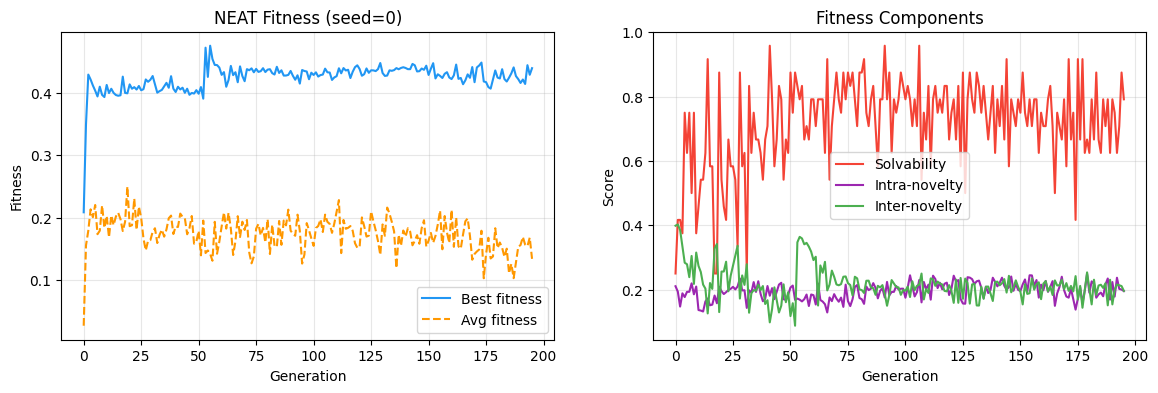

Gen   0/200 |..................................................| Best: 0.208 Avg:0.027 Solve:0.25 Intra:0.210 Inter:0.399 ME:9/16 ETA:0.0m
Gen  20/200 |#####.............................................| Best: 0.413 Avg:0.186 Solve:0.54 Intra:0.195 Inter:0.256 ME:11/16 ETA:18.4m
Gen  40/200 |##########........................................| Best: 0.401 Avg:0.186 Solve:0.71 Intra:0.211 Inter:0.167 ME:12/16 ETA:17.6m
Gen  60/200 |###############...................................| Best: 0.428 Avg:0.186 Solve:0.79 Intra:0.183 Inter:0.292 ME:13/16 ETA:16.6m
Gen  80/200 |####################..............................| Best: 0.437 Avg:0.197 Solve:0.88 Intra:0.174 Inter:0.200 ME:13/16 ETA:15.8m
Gen 100/200 |#########################.........................| Best: 0.428 Avg:0.155 Solve:0.79 Intra:0.175 Inter:0.196 ME:13/16 ETA:15.0m
Gen 120/200 |##############################....................| Best: 0.438 Avg:0.153 Solve:0.75 Intra:0.202 Inter:0.196 ME:13/16 ETA:13.4m
Gen 140/200 |##

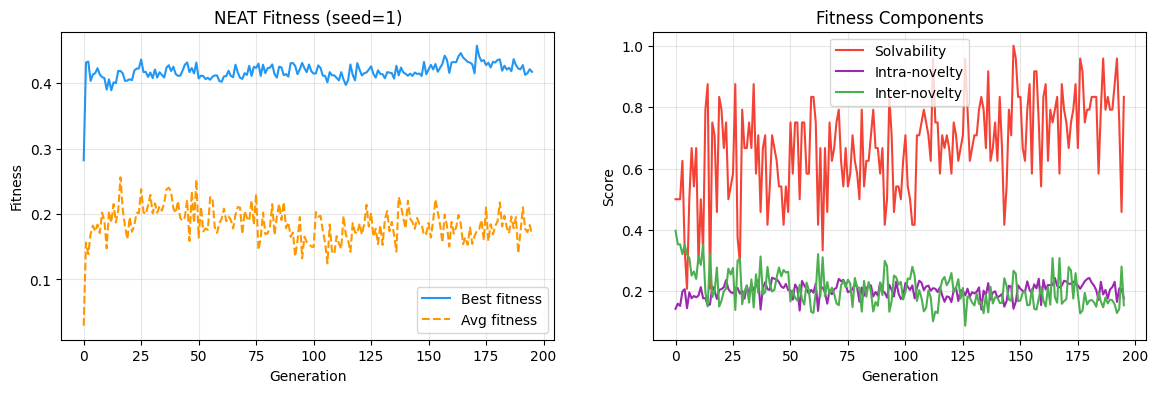

Gen   0/200 |..................................................| Best: 0.282 Avg:0.029 Solve:0.50 Intra:0.143 Inter:0.397 ME:9/16 ETA:0.0m
Gen  20/200 |#####.............................................| Best: 0.406 Avg:0.195 Solve:0.79 Intra:0.207 Inter:0.170 ME:12/16 ETA:18.5m
Gen  40/200 |##########........................................| Best: 0.414 Avg:0.201 Solve:0.42 Intra:0.207 Inter:0.280 ME:13/16 ETA:18.0m
Gen  60/200 |###############...................................| Best: 0.402 Avg:0.193 Solve:0.83 Intra:0.196 Inter:0.130 ME:13/16 ETA:16.9m
Gen  80/200 |####################..............................| Best: 0.423 Avg:0.170 Solve:0.50 Intra:0.166 Inter:0.212 ME:13/16 ETA:16.1m
Gen 100/200 |#########################.........................| Best: 0.415 Avg:0.150 Solve:0.71 Intra:0.227 Inter:0.198 ME:13/16 ETA:14.6m
Gen 120/200 |##############################....................| Best: 0.421 Avg:0.186 Solve:0.58 Intra:0.165 Inter:0.260 ME:13/16 ETA:12.9m
Gen 140/200 |##

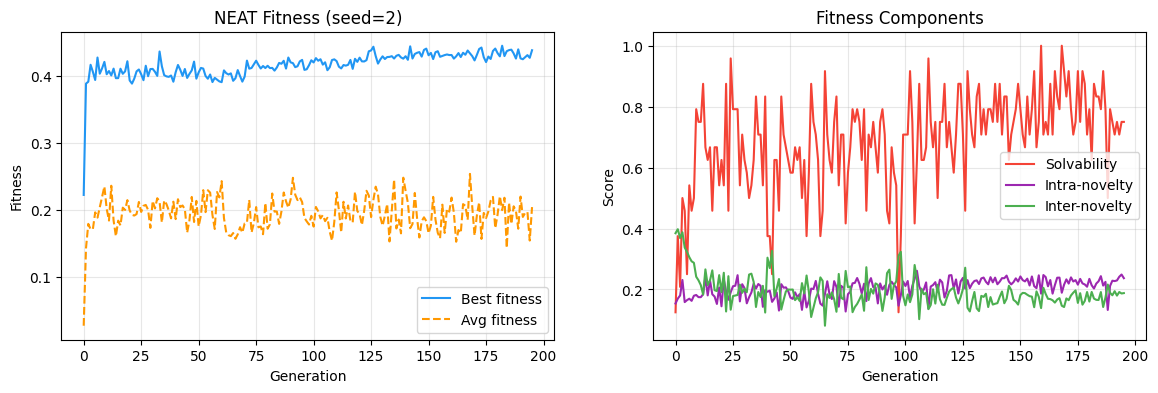

Gen   0/200 |..................................................| Best: 0.223 Avg:0.027 Solve:0.12 Intra:0.154 Inter:0.385 ME:9/16 ETA:0.0m
Gen  20/200 |#####.............................................| Best: 0.394 Avg:0.199 Solve:0.62 Intra:0.145 Inter:0.191 ME:12/16 ETA:18.2m
Gen  40/200 |##########........................................| Best: 0.406 Avg:0.187 Solve:0.38 Intra:0.192 Inter:0.304 ME:12/16 ETA:17.1m
Gen  60/200 |###############...................................| Best: 0.391 Avg:0.243 Solve:0.75 Intra:0.201 Inter:0.140 ME:12/16 ETA:16.3m
Gen  80/200 |####################..............................| Best: 0.416 Avg:0.172 Solve:0.75 Intra:0.219 Inter:0.167 ME:12/16 ETA:15.7m
Gen 100/200 |#########################.........................| Best: 0.421 Avg:0.175 Solve:0.71 Intra:0.211 Inter:0.148 ME:12/16 ETA:15.4m
Gen 120/200 |##############################....................| Best: 0.428 Avg:0.194 Solve:0.67 Intra:0.247 Inter:0.201 ME:13/16 ETA:13.6m
Gen 140/200 |##

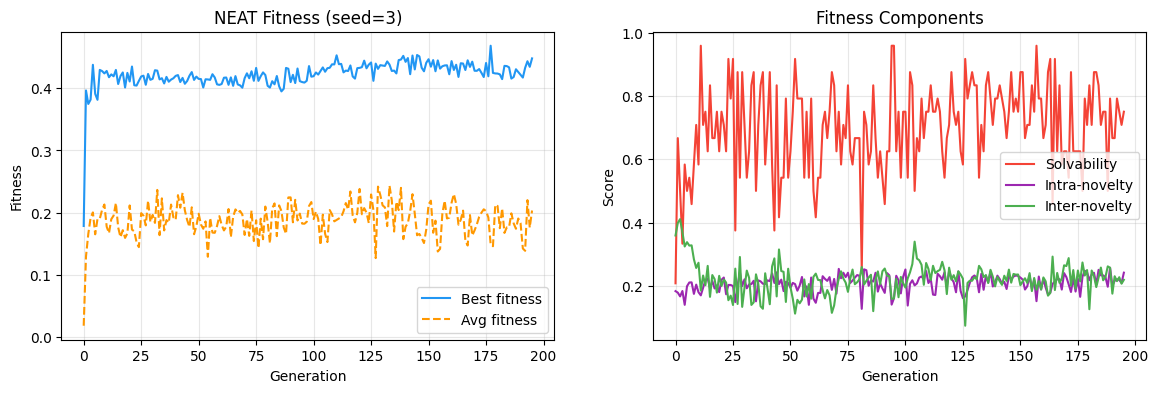

Gen   0/200 |..................................................| Best: 0.178 Avg:0.018 Solve:0.21 Intra:0.184 Inter:0.359 ME:8/16 ETA:0.0m
Gen  20/200 |#####.............................................| Best: 0.411 Avg:0.211 Solve:0.75 Intra:0.219 Inter:0.200 ME:12/16 ETA:19.7m
Gen  40/200 |##########........................................| Best: 0.420 Avg:0.188 Solve:0.71 Intra:0.218 Inter:0.193 ME:12/16 ETA:18.5m
Gen  60/200 |###############...................................| Best: 0.407 Avg:0.180 Solve:0.50 Intra:0.160 Inter:0.229 ME:12/16 ETA:16.9m
Gen  80/200 |####################..............................| Best: 0.404 Avg:0.185 Solve:0.67 Intra:0.232 Inter:0.221 ME:12/16 ETA:15.9m
Gen 100/200 |#########################.........................| Best: 0.419 Avg:0.189 Solve:0.75 Intra:0.252 Inter:0.195 ME:13/16 ETA:15.0m
Gen 120/200 |##############################....................| Best: 0.433 Avg:0.238 Solve:0.88 Intra:0.224 Inter:0.220 ME:13/16 ETA:13.7m
Gen 140/200 |##

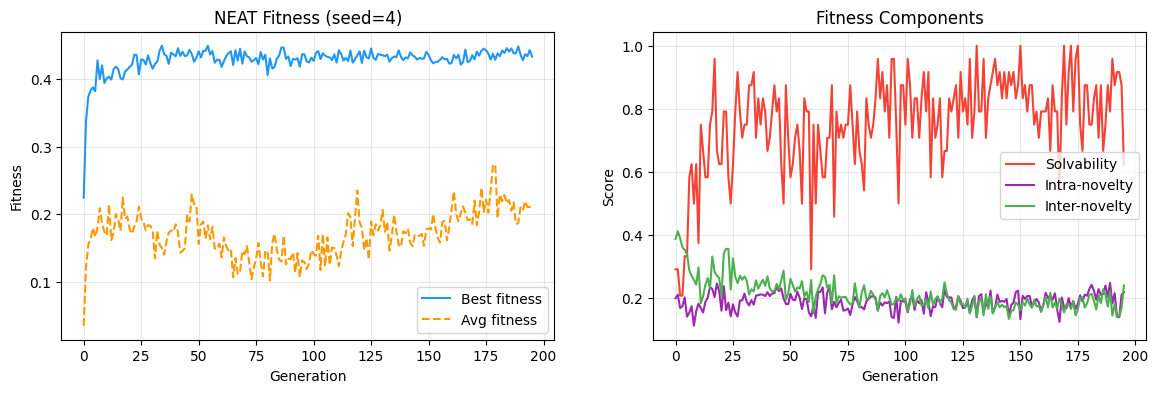

Gen   0/200 |..................................................| Best: 0.224 Avg:0.035 Solve:0.29 Intra:0.200 Inter:0.388 ME:8/16 ETA:0.0m
Gen  20/200 |#####.............................................| Best: 0.418 Avg:0.177 Solve:0.62 Intra:0.160 Inter:0.206 ME:12/16 ETA:18.3m
Gen  40/200 |##########........................................| Best: 0.434 Avg:0.185 Solve:0.67 Intra:0.219 Inter:0.270 ME:13/16 ETA:17.0m
Gen  60/200 |###############...................................| Best: 0.418 Avg:0.136 Solve:0.75 Intra:0.177 Inter:0.152 ME:13/16 ETA:15.8m
Gen  80/200 |####################..............................| Best: 0.406 Avg:0.145 Solve:0.67 Intra:0.172 Inter:0.171 ME:13/16 ETA:14.4m
Gen 100/200 |#########################.........................| Best: 0.427 Avg:0.141 Solve:0.75 Intra:0.189 Inter:0.199 ME:13/16 ETA:13.1m
Gen 120/200 |##############################....................| Best: 0.441 Avg:0.188 Solve:0.79 Intra:0.202 Inter:0.186 ME:13/16 ETA:11.7m
Gen 140/200 |##

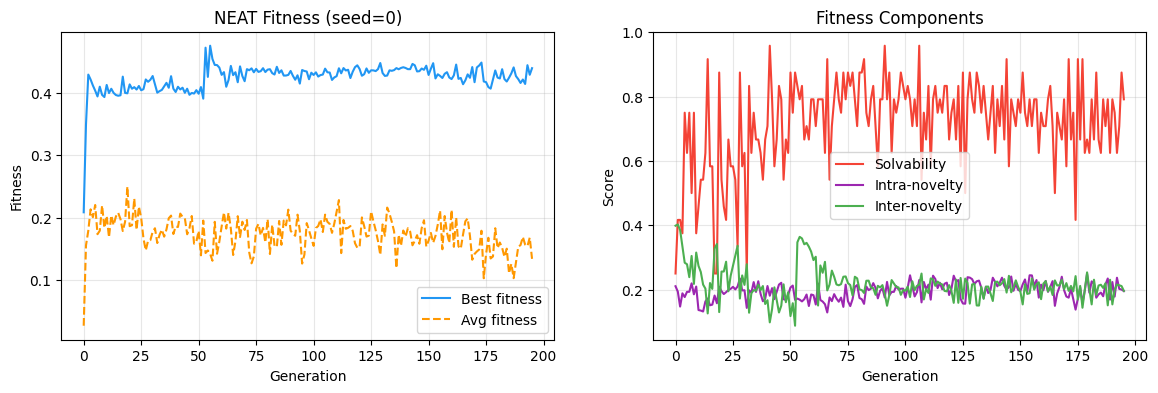

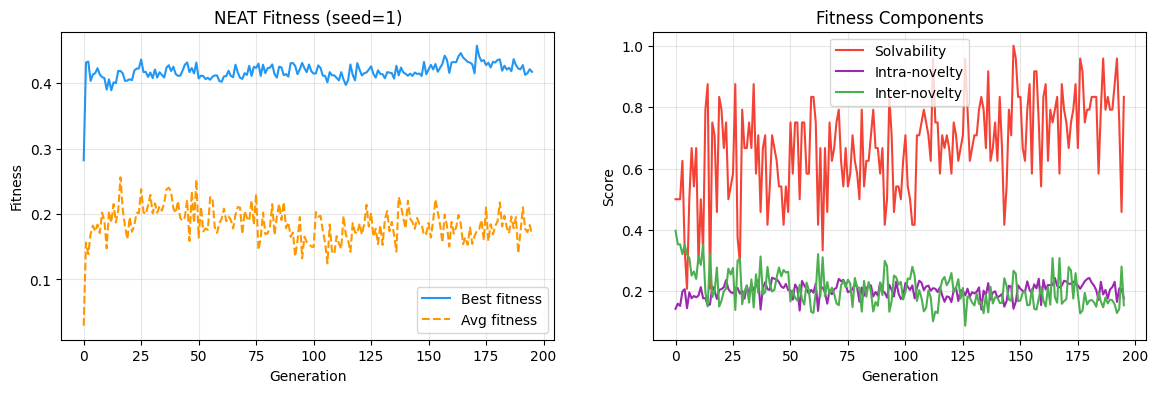

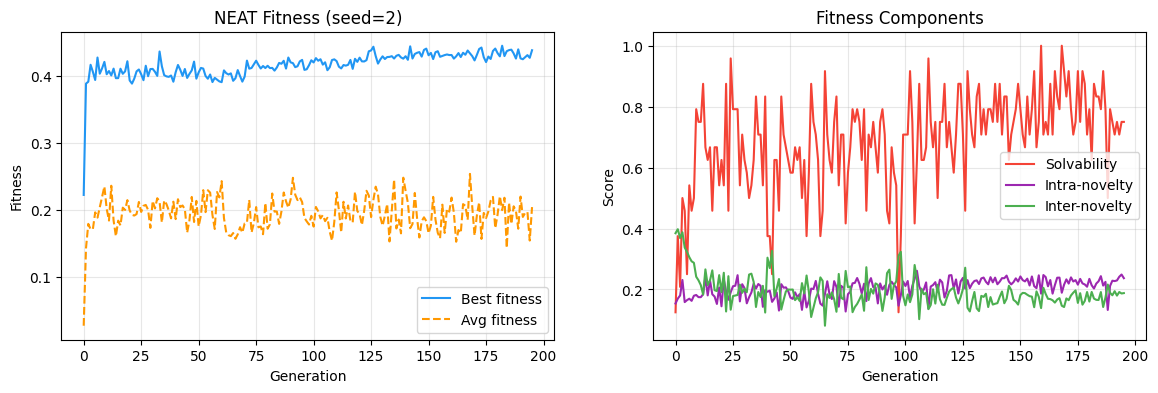

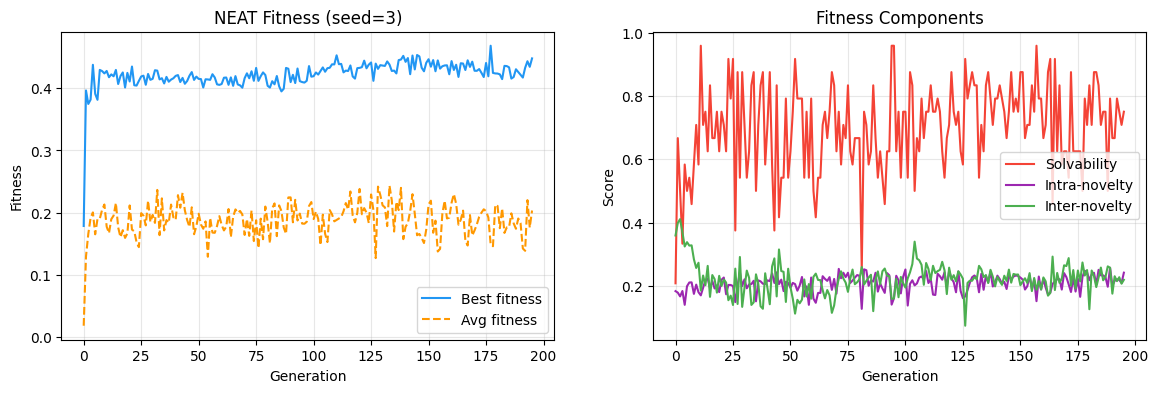

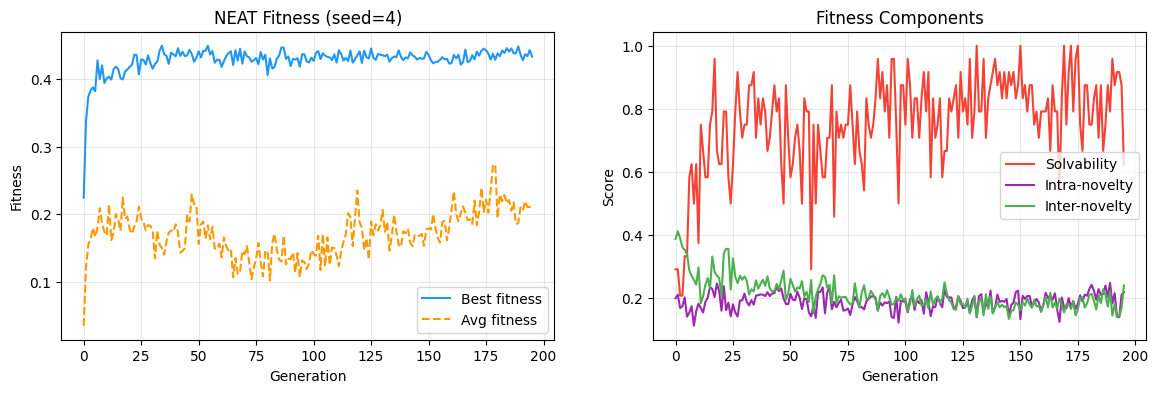

In [8]:
class PCGNNReporter(neat.reporting.BaseReporter):
    def __init__(self, log_interval=10, live_plot_interval=5, seed=0):
        self.log_interval       = log_interval
        self.live_plot_interval = live_plot_interval
        self.generations  = []
        self.best_fitness = []
        self.avg_fitness  = []
        self.intra_scores = []
        self.inter_scores = []
        self.solve_scores = []
        self.start_time   = None

        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 4))
        self.bl, = self.ax1.plot([], [], label="Best fitness", color="#2196F3")
        self.al, = self.ax1.plot([], [], label="Avg fitness",  color="#FF9800", linestyle="--")
        self.ax1.set(xlabel="Generation", ylabel="Fitness", title=f"NEAT Fitness (seed={seed})")
        self.ax1.legend(); self.ax1.grid(True, alpha=0.3)
        self.ax2.set(xlabel="Generation", ylabel="Score", title="Fitness Components")
        self.ax2.grid(True, alpha=0.3)

        self.display_id = f"pcgnn-live-{seed}"
        display(self.fig, display_id=self.display_id)

    def start_generation(self, generation):
        if generation == 0:
            self.start_time = time.time()

    def post_evaluate(self, config, population, species, best_genome):
        gen = len(self.generations)
        self.generations.append(gen)

        fits = [g.fitness for g in population.values() if g.fitness is not None]
        best = max(fits); avg = np.mean(fits)
        self.best_fitness.append(best); self.avg_fitness.append(avg)

        best_net = neat.nn.RecurrentNetwork.create(best_genome, config)
        sample_levels = [generate_level(best_net) for _ in range(MAPS_PER_GENOME)]
        intra = intra_novelty_score(sample_levels, k=10)
        inter = inter_novelty_score(sample_levels, novelty_archive) if novelty_archive else 0.0
        solve = solvability_fitness(sample_levels)
        self.intra_scores.append(intra); self.inter_scores.append(inter)
        self.solve_scores.append(solve)

        elapsed = time.time() - self.start_time
        eta = (elapsed / (gen+1)) * (MAX_GEN - gen - 1) if gen > 0 else 0
        bar = '#' * int(50*(gen+1)/MAX_GEN) + '.' * (50 - int(50*(gen+1)/MAX_GEN))
        print(f"\rGen {gen:3d}/{MAX_GEN} |{bar}| Best:{best:6.3f} Avg:{avg:5.3f} "
              f"Solve:{solve:.2f} Intra:{intra:.3f} Inter:{inter:.3f} "
              f"ME:{len(me_archive)}/{ME_TOTAL_CELLS} ETA:{eta/60:.1f}m",
              end='', flush=True)
        if gen % self.log_interval == 0:
            print()

        if gen % self.live_plot_interval == 0:
            self.bl.set_data(self.generations, self.best_fitness)
            self.al.set_data(self.generations, self.avg_fitness)
            self.ax1.relim(); self.ax1.autoscale_view()

            self.ax2.cla()
            self.ax2.plot(self.generations, self.solve_scores,  label="Solvability", color="#F44336")
            self.ax2.plot(self.generations, self.intra_scores,  label="Intra-novelty", color="#9C27B0")
            self.ax2.plot(self.generations, self.inter_scores,  label="Inter-novelty", color="#4CAF50")
            self.ax2.set(xlabel="Generation", ylabel="Score", title="Fitness Components")
            self.ax2.legend(); self.ax2.grid(True, alpha=0.3)
            update_display(self.fig, display_id=self.display_id)


# ─────────────────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────────────────
all_winners   = {}
all_reporters = {}

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"  Seed {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})")
    print(f"{'='*60}")

    random.seed(seed)
    np.random.seed(seed)
    novelty_archive = []
    me_archive.clear()
    reset_level_cache()
    reset_bc_cache()
    reset_aed_cache()

    config = neat.Config(
        neat.DefaultGenome,
        neat.DefaultReproduction,
        neat.DefaultSpeciesSet,
        neat.DefaultStagnation,
        CONFIG_PATH
    )
    pop      = neat.Population(config)
    reporter = PCGNNReporter(log_interval=20, live_plot_interval=5, seed=seed)
    pop.add_reporter(reporter)
    pop.add_reporter(neat.StatisticsReporter())

    winner = pop.run(eval_genomes, MAX_GEN)

    all_winners[seed]   = (winner, config)
    all_reporters[seed] = reporter

    path = f"neat_winner_seed{seed}.pkl"
    with open(path, "wb") as f:
        pickle.dump(winner, f)
    print(f"\nSeed {seed} done -> {path}")

print(f"\nAll {len(SEEDS)} seeds trained!")


## Cell 8 - Convergence & Novelty Plot

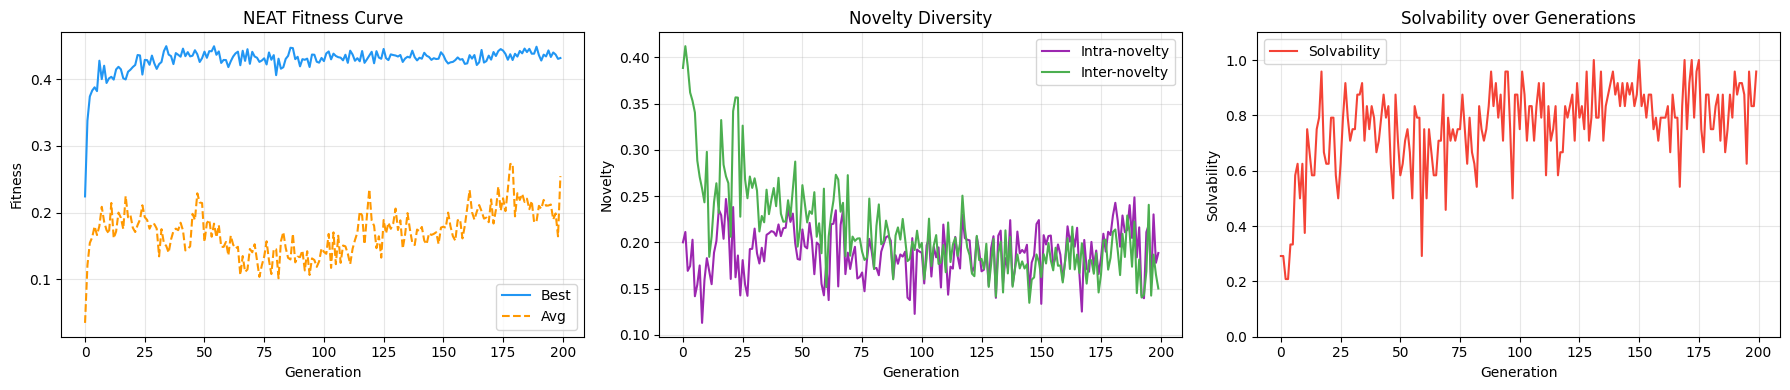

✅ Saved training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(reporter.generations, reporter.best_fitness, label="Best", color="#2196F3")
axes[0].plot(reporter.generations, reporter.avg_fitness,  label="Avg",  color="#FF9800", linestyle="--")
axes[0].set(xlabel="Generation", ylabel="Fitness", title="NEAT Fitness Curve")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(reporter.generations, reporter.intra_scores, label="Intra-novelty", color="#9C27B0")
axes[1].plot(reporter.generations, reporter.inter_scores, label="Inter-novelty", color="#4CAF50")
axes[1].set(xlabel="Generation", ylabel="Novelty", title="Novelty Diversity")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(reporter.generations, reporter.solve_scores, label="Solvability", color="#F44336")
axes[2].set(xlabel="Generation", ylabel="Solvability", title="Solvability over Generations")
axes[2].set_ylim([0, 1.1]); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved training_curves.png")

## Cell 9 - Load Model & Generate Maps

Seed 0: 100 maps generated
Seed 1: 100 maps generated
Seed 2: 100 maps generated
Seed 3: 100 maps generated
Seed 4: 100 maps generated


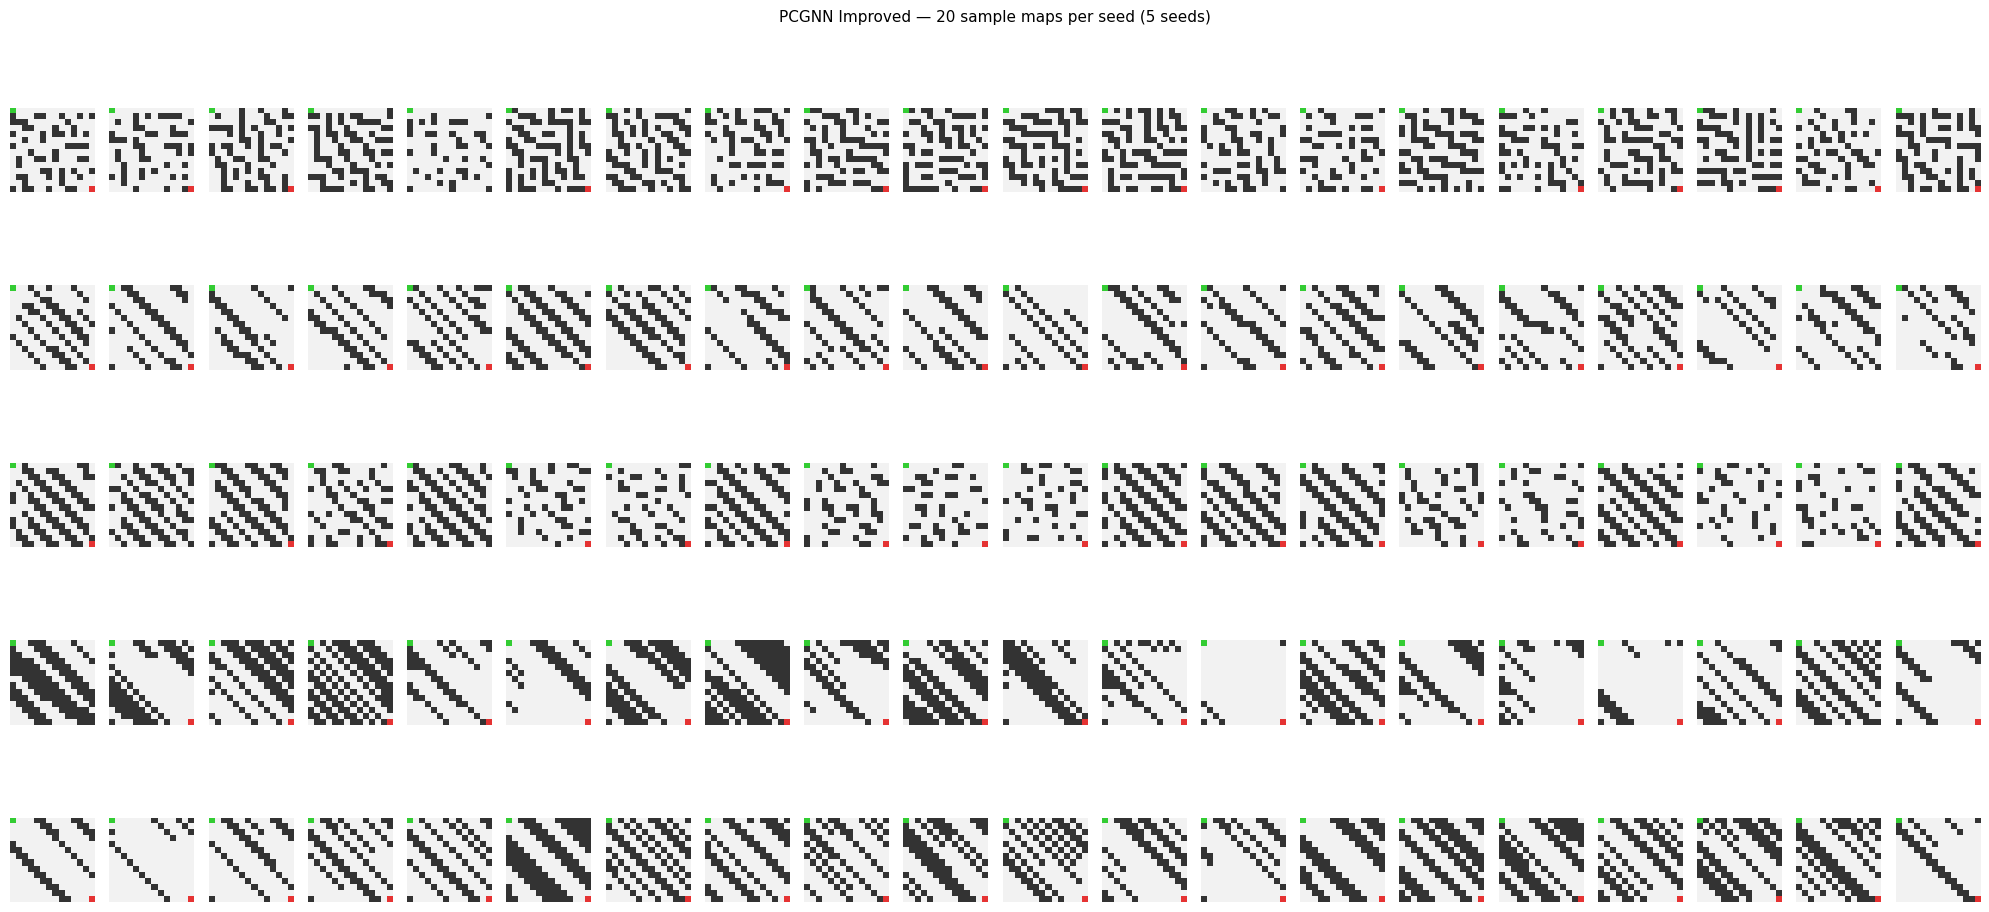


✅ loaded_net = seed 4 (for generalisability test)


In [10]:
N_MAPS_EVAL   = 100              # paper: NUM_LEVELS=100 (experiment.py line 18)
N_MAPS_SHOW   = 20
all_seed_maps = {}

fig, axs = plt.subplots(len(SEEDS), N_MAPS_SHOW, figsize=(20, len(SEEDS) * 2), squeeze=False)

for si, seed in enumerate(SEEDS):
    winner_genome, cfg = all_winners[seed]
    net = neat.nn.RecurrentNetwork.create(winner_genome, cfg)

    maps = [generate_level(net) for _ in range(N_MAPS_EVAL)]
    all_seed_maps[seed] = maps

    for j in range(N_MAPS_SHOW):
        lvl = maps[j]
        h, w = lvl.shape
        img = np.zeros((h, w, 3))
        for tile, color in TILE_COLORS.items():
            img[lvl == tile] = color
        axs[si, j].imshow(img, interpolation="nearest")
        axs[si, j].axis("off")
    axs[si, 0].set_ylabel(f"Seed\n{seed}", fontsize=7, rotation=0, labelpad=28, va="center")

    print(f"Seed {seed}: {N_MAPS_EVAL} maps generated")

plt.suptitle(f"PCGNN Improved — {N_MAPS_SHOW} sample maps per seed ({len(SEEDS)} seeds)", fontsize=11)
plt.tight_layout()
plt.show()

loaded_net  = neat.nn.RecurrentNetwork.create(all_winners[SEEDS[-1]][0], all_winners[SEEDS[-1]][1])
loaded_maps = all_seed_maps[SEEDS[-1]]
print(f"\n✅ loaded_net = seed {SEEDS[-1]} (for generalisability test)")

## Cell 10 - Evaluate Final Maps (Paper Metrics: Solvability, Compression Distance, A* Diversity, Leniency)

In [11]:
def compute_seed_metrics(maps):
    per_level = []
    for lvl in maps:
        sp = shortest_path_bfs(lvl)
        per_level.append({
            "solvable"  : is_solvable(lvl),
            "path_len"  : sp if sp else 0,
            "wall_dens" : interior_wall_density(lvl),
            "leniency"  : leniency(lvl),
            "astar_diff": astar_difficulty(lvl),
            "reach"     : reachability_ratio(lvl),
        })

    n = len(maps)
    comp_dists, astar_divs, astar_edits, vis_divs = [], [], [], []
    for i in range(n):
        for j in range(i+1, n):
            comp_dists.append(compression_distance(maps[i], maps[j]))
            astar_divs.append(astar_diversity(maps[i], maps[j]))
            astar_edits.append(astar_edit_diversity(maps[i], maps[j]))
            vis_divs.append(visual_diversity(maps[i], maps[j]))

    return {
        "solvability": float(np.mean([r["solvable"]    for r in per_level])),
        "path_len"   : float(np.mean([r["path_len"]    for r in per_level])),
        "wall_dens"  : float(np.mean([r["wall_dens"]   for r in per_level])),
        "leniency"   : float(np.mean([r["leniency"]    for r in per_level])),
        "astar_diff" : float(np.mean([r["astar_diff"]  for r in per_level])),
        "reach"      : float(np.mean([r["reach"]       for r in per_level])),
        "comp_dist"  : float(np.mean(comp_dists)),
        "astar_div"  : float(np.mean(astar_divs)),
        "astar_edit" : float(np.mean(astar_edits)),
        "vis_div"    : float(np.mean(vis_divs)),
    }


print("Computing metrics across all seeds (takes a while)...\n")
seed_results = {}

for seed in SEEDS:
    print(f"  Seed {seed}...", end=" ", flush=True)
    seed_results[seed] = compute_seed_metrics(all_seed_maps[seed])
    m = seed_results[seed]
    print(f"solve={m['solvability']*100:.0f}%  reach={m['reach']:.3f}  "
          f"astar_diff={m['astar_diff']:.3f}  astar_div={m['astar_div']:.4f}")


def agg(key):
    vals = [seed_results[s][key] for s in SEEDS]
    return np.mean(vals), np.std(vals)

print("\n" + "═"*62)
print("  PCGNN Improved — mean ± std  (5 seeds, 100 maps each)")
print("═"*62)

solve_m, solve_s = agg("solvability")
wall_m,  wall_s  = agg("wall_dens")
len_m,   len_s   = agg("path_len")
leni_m,  leni_s  = agg("leniency")
diff_m,  diff_s  = agg("astar_diff")
reach_m, reach_s = agg("reach")
comp_m,  comp_s  = agg("comp_dist")
adiv_m,  adiv_s  = agg("astar_div")
aedit_m, aedit_s = agg("astar_edit")
vdiv_m,  vdiv_s  = agg("vis_div")

print(f"  ── Quality ────────────────────────────────────────")
print(f"  Solvability          {solve_m*100:5.1f}% ± {solve_s*100:.1f}%   (paper: 100%)")
print(f"  Avg path length      {len_m:6.1f}  ± {len_s:.1f}")
print(f"  Wall density         {wall_m:.4f} ± {wall_s:.4f}")
print(f"  Reachability ratio   {reach_m:.4f} ± {reach_s:.4f}   (cải tiến: ↑ better)")
print(f"")
print(f"  ── Difficulty (Table 4) ───────────────────────────")
print(f"  Leniency             {leni_m:.4f} ± {leni_s:.4f}   (paper: 0.70 ± 0.08)")
print(f"  A* Difficulty        {diff_m:.4f} ± {diff_s:.4f}   (paper: 0.06 ± 0.08)")
print(f"")
print(f"  ── Diversity (Table 3) ────────────────────────────")
print(f"  Compression Dist     {comp_m:.4f} ± {comp_s:.4f}   (paper: 0.488 ± 0.002)")
print(f"  A* Diversity         {adiv_m:.4f} ± {adiv_s:.4f}   (paper: 0.13 ± 0.17)")
print(f"  A* Edit Diversity    {aedit_m:.4f} ± {aedit_s:.4f}   (paper: 0.135 ± 0.167)")
print(f"  Visual Diversity     {vdiv_m:.4f} ± {vdiv_s:.4f}")
print("═"*62)

print("\nPer-seed breakdown:")
print(f"  {'Seed':>6}  {'Solve':>6}  {'Reach':>6}  {'Leniency':>8}  {'A*Diff':>7}  {'CompDist':>8}  {'A*Div':>6}")
for s in SEEDS:
    m = seed_results[s]
    print(f"  {s:>6}  {m['solvability']*100:>5.1f}%  {m['reach']:>6.4f}  {m['leniency']:>8.4f}  "
          f"{m['astar_diff']:>7.4f}  {m['comp_dist']:>8.4f}  {m['astar_div']:>6.4f}")

Computing metrics across all seeds (takes a while)...

  Seed 0... solve=79%  reach=0.922  astar_diff=0.399  astar_div=0.2051
  Seed 1... solve=92%  reach=0.627  astar_diff=0.314  astar_div=0.1240
  Seed 2... solve=78%  reach=0.679  astar_diff=0.303  astar_div=0.1993
  Seed 3... solve=74%  reach=0.663  astar_diff=0.358  astar_div=0.2180
  Seed 4... solve=94%  reach=0.556  astar_diff=0.324  astar_div=0.1014

══════════════════════════════════════════════════════════════
  PCGNN Improved — mean ± std  (5 seeds, 100 maps each)
══════════════════════════════════════════════════════════════
  ── Quality ────────────────────────────────────────
  Solvability           83.4% ± 8.0%   (paper: 100%)
  Avg path length        21.7  ± 2.1
  Wall density         0.3269 ± 0.0361
  Reachability ratio   0.6891 ± 0.1237   (cải tiến: ↑ better)

  ── Difficulty (Table 4) ───────────────────────────
  Leniency             0.6785 ± 0.1057   (paper: 0.70 ± 0.08)
  A* Difficulty        0.3396 ± 0.0349   (pap

## Cell 11 - Generalisability Test (paper Section 5.5)

Testing generalisability across different map sizes...
(Trained on 8x8–16x16, testing on larger sizes)

  Size    8×8    | Gen time: 1.6ms | Solvability: 100%
  Size   14×14   | Gen time: 4.5ms | Solvability: 100%
  Size   20×20   | Gen time: 9.1ms | Solvability: 100%
  Size   30×30   | Gen time: 19.9ms | Solvability: 100%
  Size   50×50   | Gen time: 56.5ms | Solvability: 90%
  Size  100×100  | Gen time: 230.5ms | Solvability: 90%


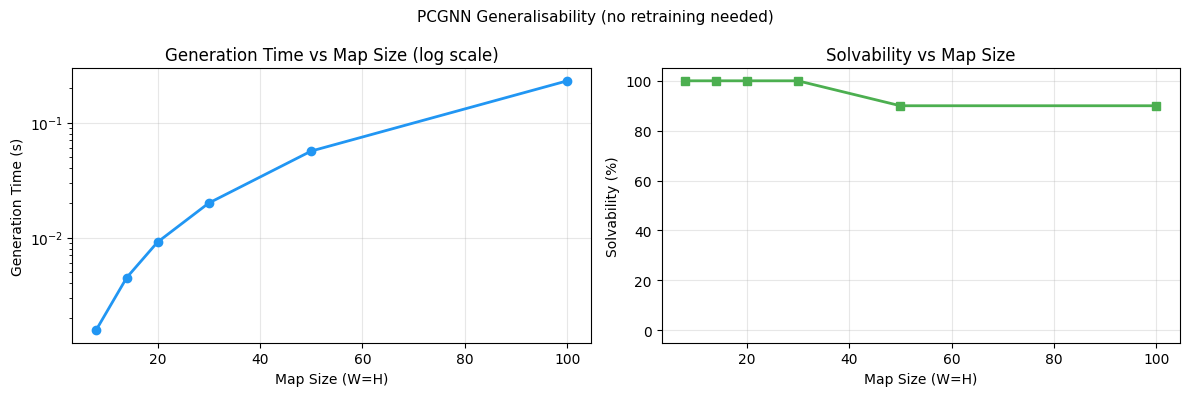


✅ Generalisability test complete


In [12]:
# Paper Section 5.5: test generate level ở size khác với size training
# PCGNN generalizes vì dùng sliding context window, không fixed-size input

print("Testing generalisability across different map sizes...")
print("(Trained on 8x8–16x16, testing on larger sizes)\n")

test_sizes = [8, 14, 20, 30, 50, 100]
gen_times  = []
solv_rates = []
N_TEST     = 10

for sz in test_sizes:
    t0 = time.time()
    maps_sz = []
    for _ in range(N_TEST):
        lvl = generate_level(loaded_net, map_h=sz, map_w=sz)
        maps_sz.append(lvl)
    elapsed = (time.time() - t0) / N_TEST
    solve_r = np.mean([float(is_solvable(m)) for m in maps_sz])
    gen_times.append(elapsed)
    solv_rates.append(solve_r)
    print(f"  Size {sz:4d}×{sz:<4d} | Gen time: {elapsed*1000:.1f}ms | Solvability: {solve_r*100:.0f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(test_sizes, gen_times, "o-", color="#2196F3", linewidth=2)
ax1.set(xlabel="Map Size (W=H)", ylabel="Generation Time (s)",
        title="Generation Time vs Map Size (log scale)")
ax1.grid(True, alpha=0.3)

ax2.plot(test_sizes, [s*100 for s in solv_rates], "s-", color="#4CAF50", linewidth=2)
ax2.set(xlabel="Map Size (W=H)", ylabel="Solvability (%)",
        title="Solvability vs Map Size")
ax2.set_ylim([-5, 105]); ax2.grid(True, alpha=0.3)

plt.suptitle("PCGNN Generalisability (no retraining needed)", fontsize=11)
plt.tight_layout()
plt.savefig("generalisability.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ Generalisability test complete")

## Cell 12 - Export ZIP

In [13]:
import shutil
shutil.make_archive('/kaggle/working/saved_maps', 'zip', '/kaggle/working/saved_maps_txt')
print("✅ saved_maps.zip ready for download")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/saved_maps_txt'